In [6]:
import pandas as pd
import sklearn.ensemble as rf
import matplotlib.pyplot as plt
import sklearn.model_selection as ms
import sklearn.preprocessing as pp
import sklearn.tree as tree
import numpy as np

In [2]:
df = pd.read_csv("data/heartdisease/data_cleaned_up.csv")
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
0,28,1,2,130,132,0,2,185,0,0.0,0
1,29,1,2,120,243,0,0,160,0,0.0,0
2,30,0,1,170,237,0,1,170,0,0.0,0
3,31,0,2,100,219,0,1,150,0,0.0,0
4,32,0,2,105,198,0,0,165,0,0.0,0
5,32,1,2,110,225,0,0,184,0,0.0,0
6,32,1,2,125,254,0,0,155,0,0.0,0
7,33,1,3,120,298,0,0,185,0,0.0,0
8,34,0,2,130,161,0,0,190,0,0.0,0
9,34,1,2,150,214,0,1,168,0,0.0,0


In [3]:
x = df.drop("num", axis=1)
y = df["num"]
xtrain, xtest, ytrain, ytest = ms.train_test_split(x,y,train_size=0.8, test_size=0.2)


In [4]:
# scaler = pp.MinMaxScaler()
# scaler = pp.StandardScaler()
scaler = pp.RobustScaler()
scaler.fit(xtrain)
xtrain = scaler.transform(xtrain)
xtest = scaler.transform(xtest)
test = pd.DataFrame(xtrain)
test

,0,1,2,3,4,5,6,7,8,9
0,0.000000,0.0,0.0,-0.75,0.269360,0.0,0.0,1.111111,0.0,0.0
1,-0.166667,-1.0,0.0,0.25,0.040404,1.0,0.0,0.952381,0.0,0.0
2,-0.416667,0.0,0.5,0.00,0.606061,0.0,0.0,-1.269841,1.0,2.0
3,-0.916667,0.0,0.0,0.75,0.632997,0.0,0.0,-0.317460,0.0,0.0
4,-0.166667,0.0,0.5,0.50,0.417508,1.0,0.0,-0.476190,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
203,0.416667,0.0,0.5,3.50,-0.632997,0.0,0.0,0.063492,1.0,2.0
204,-0.750000,-1.0,0.5,1.00,1.979798,0.0,0.0,-0.317460,0.0,2.0
205,-1.083333,0.0,-0.5,-0.50,0.296296,0.0,0.0,0.634921,0.0,3.0
206,1.333333,0.0,0.5,2.00,0.242424,1.0,0.0,-0.888889,1.0,2.0


In [9]:
model = rf.RandomForestClassifier(n_estimators=100)
model.fit(xtrain, ytrain)
model.score(xtest, ytest)

0.75

In [10]:
tree.export_graphviz(model.estimators_[0], out_file="data/heartdisease/tree.dot", feature_names=x.columns, class_names=["0", "1"])


In [12]:
model.feature_importances_

array([0.08428578, 0.05220637, 0.19509671, 0.08142336, 0.12522723,
       0.0117196 , 0.01630568, 0.12264674, 0.11377945, 0.1973091 ])

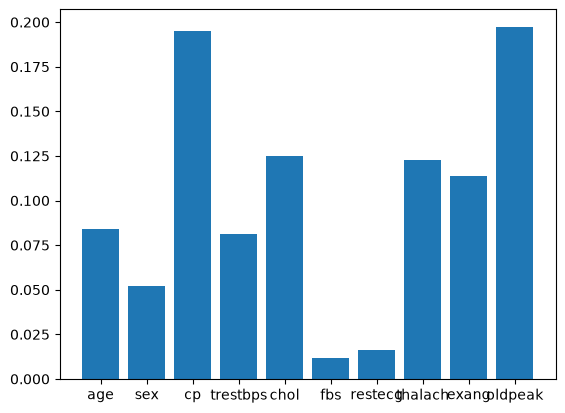

In [13]:
plt.bar(x.columns, model.feature_importances_)
plt.show()

In [14]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,num
age,1.000000,0.021871,0.142730,0.256381,0.096155,0.197968,0.051370,-0.459304,0.270514,0.211932,0.158399
sex,0.021871,1.000000,0.217747,0.096748,0.056435,0.068355,-0.080355,-0.074397,0.126754,0.119016,0.251784
cp,0.142730,0.217747,1.000000,0.079571,0.161075,0.044559,0.006507,-0.390338,0.483343,0.360710,0.503825
trestbps,0.256381,0.096748,0.079571,1.000000,0.116153,0.114365,0.020958,-0.219564,0.236982,0.232377,0.146476
chol,0.096155,0.056435,0.161075,0.116153,1.000000,0.124658,0.056334,-0.135736,0.175350,0.114962,0.217275
fbs,0.197968,0.068355,0.044559,0.114365,0.124658,1.000000,0.021614,-0.082380,0.127458,0.070403,0.178039
restecg,0.051370,-0.080355,0.006507,0.020958,0.056334,0.021614,1.000000,-0.010130,0.059650,0.025278,-0.020881
thalach,-0.459304,-0.074397,-0.390338,-0.219564,-0.135736,-0.082380,-0.010130,1.000000,-0.430697,-0.329947,-0.344058
exang,0.270514,0.126754,0.483343,0.236982,0.175350,0.127458,0.059650,-0.430697,1.000000,0.639506,0.565214
oldpeak,0.211932,0.119016,0.360710,0.232377,0.114962,0.070403,0.025278,-0.329947,0.639506,1.000000,0.570173
